# Streamflow Forecasting: Model Performance Report
Stephen Huysman
March 31, 2026

**Transfer Learning with NeuralHydrology, CudaLSTM**

This notebook documents the current state of the streamflow forecasting models for two National Park watersheds:

- **Lamar River** (Yellowstone NP): snowmelt-dominated, high lag-1 autocorrelation (0.980)
- **Hoh River** (Olympic NP): rain-dominated, moderate lag-1 autocorrelation (0.748)

**Approach:** A CudaLSTM model pre-trained on 531 CAMELS US basins (Kratzert et al. 2024) is fine-tuned on each individual watershed using local GridMET climate data. This model is compared to a per-basin baseline model trained from scratch using only local training data.

**Test period:** October 2020 – December 2025

**Summary of Findings:** Overall accuracy is similar between transfer learning and from-scratch models for Lamar (NSE 0.91 vs 0.89), while transfer learning provides a moderate improvement on Hoh (KGE 0.81 vs 0.76). The strongest case for transfer learning on Lamar is better peak-flow prediction, particularly for the June 2022 flood event. The results shown here are retrospective evaluations on historical forcings; operational performance with downscaled MetData CFSv2 forecasts is still untested and will need separate verification.

> **Note on units:** The model internally predicts streamflow in mm/day (runoff depth normalized by basin area), which is standard in the NeuralHydrology / CAMELS framework. All values in this report have been converted to **cubic feet per second (CFS)** for practical interpretation. Dimensionless metrics (NSE, KGE, Pearson r) are unaffected by this conversion.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams.update({
    'figure.figsize': (12, 4),
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Basin areas (km²) from GAGES-II, used for mm/day → CFS conversion
BASIN_AREAS = {'lamar_lumped': 1730.1, 'hoh_lumped': 655.3}

def mm_per_day_to_cfs(values, area_km2):
    """Convert mm/day over a basin to cubic feet per second."""
    # mm/day → m³/s → cfs
    return values * area_km2 * 1000.0 / 86400.0 * 35.3147

# Load results and convert to CFS
def load_results(run_dir, basin, epoch=30):
    path = f"runs/{run_dir}/test/model_epoch{epoch:03d}/test_results.p"
    with open(path, 'rb') as f:
        results = pickle.load(f)
    data = results[basin]['1D']
    ds = data['xr']
    obs = ds['QObs_mm_d_obs'].values.squeeze()
    sim = ds['QObs_mm_d_sim'].values.squeeze()
    dates = pd.DatetimeIndex(ds.date.values)
    
    # Convert to CFS
    area = BASIN_AREAS[basin]
    obs_cfs = mm_per_day_to_cfs(obs, area)
    sim_cfs = mm_per_day_to_cfs(sim, area)
    
    metrics = {k: data[k] for k in ['NSE', 'KGE', 'RMSE', 'Pearson-r']}
    # Convert RMSE to CFS (same linear transform)
    metrics['RMSE'] = mm_per_day_to_cfs(metrics['RMSE'], area)
    
    return dates, obs_cfs, sim_cfs, metrics

# Lamar fine-tuned
lamar_ft_dates, lamar_ft_obs, lamar_ft_sim, lamar_ft_metrics = load_results(
    'lamar_finetune_3var_2703_151549', 'lamar_lumped')

# Hoh fine-tuned
hoh_ft_dates, hoh_ft_obs, hoh_ft_sim, hoh_ft_metrics = load_results(
    'hoh_finetune_3var_2703_153640', 'hoh_lumped')

# Scratch baselines (separate per-basin models, hidden_size=32, 100 epochs)
lamar_sc_dates, lamar_sc_obs, lamar_sc_sim, lamar_sc_metrics = load_results(
    'lamar_scratch_3var_3103_161906', 'lamar_lumped', epoch=100)
hoh_sc_dates, hoh_sc_obs, hoh_sc_sim, hoh_sc_metrics = load_results(
    'hoh_scratch_3var_3103_161959', 'hoh_lumped', epoch=100)

print("Data loaded successfully (all flows in CFS).")

Data loaded successfully (all flows in CFS).


In [2]:
# Verify lag-1 autocorrelation from the full streamflow record
import xarray as xr

for basin in ['lamar_lumped', 'hoh_lumped']:
    ds = xr.open_dataset(f'data/neuralhydrology/time_series/{basin}.nc')
    q = pd.Series(ds['QObs_mm_d'].values.squeeze(), index=pd.DatetimeIndex(ds.date.values)).dropna()
    print(f'{basin}: lag-1 autocorrelation = {q.autocorr(1):.3f} (n={len(q)}, {q.index[0].date()} to {q.index[-1].date()})')

lamar_lumped: lag-1 autocorrelation = 0.980 (n=13146, 1990-01-01 to 2025-12-31)
hoh_lumped: lag-1 autocorrelation = 0.748 (n=13148, 1990-01-01 to 2025-12-30)


## 1. Data Pipeline

Raw data sources are processed through a 4-step pipeline in `transfer_learning/src/`:

| Step | Script | Description |
|------|--------|-------------|
| 1 | `01_prep_climate_lumped.py` | Lump GridMET elevation-band climate to basin-mean |
| 2 | `02_convert_streamflow.py` | Convert USGS streamflow from CFS to mm/day |
| 3 | `03_merge_to_netcdf.py` | Merge climate + streamflow into NeuralHydrology NetCDF |
| 4 | `04_calculate_attributes.py` | Calculate 7 static basin attributes from geospatial data |

**Dynamic inputs (3):** `prcp_mm_day`, `tmax_C`, `tmin_C` (daily GridMET)

**Static attributes (7):**

| Attribute | Lamar | Hoh | Source |
|-----------|-------|-----|--------|
| `area_gages2` | 1730.1 km² | 655.3 km² | USGS gage metadata (authoritative) |
| `elev_mean` | 2540.8 m | 735.2 m | USGS 3DEP 30m DEM, zonal mean |
| `slope_mean` | 16.6° | 23.9° | Derived from 3DEP DEM gradient |
| `frac_forest` | 0.320 | 0.794 | NLCD 2021 (classes 41, 42, 43) |
| `soil_depth_pelletier` | 1.37 m | 1.43 m | NRCS SSURGO, component-weighted max horizon depth |
| `sand_frac` | 0.516 | 0.438 | NRCS SSURGO, component-weighted average |
| `clay_frac` | 0.181 | 0.145 | NRCS SSURGO, component-weighted average |

Static attributes are computed by `04_calculate_attributes.py`, which fetches geospatial data via WMS (3DEP, NLCD) and the SSURGO Soil Data Access REST API. Downloaded rasters are cached to `~/sync/dem_data/`. Use `--no-cache` to force re-download.

**Date splits:**
- Train: Oct 1991 – Sep 2015 (24 years)
- Validation: Oct 2015 – Sep 2020 (5 years)
- Test: Oct 2020 – Dec 2025 (5+ years)

## 2. Model Architecture & Training

Hyperparameters are sourced from Kratzert et al. (2024), Appendix A, except where noted.

### Pre-training (Kratzert et al. 2024, Appendix A1)
A CudaLSTM was pre-trained on **531 CAMELS US basins** using Daymet forcing. The pre-trained checkpoint is stored in `base_model_modified/`. These parameters are from the paper and are fixed during fine-tuning:

| Parameter | Value | Source |
|-----------|-------|--------|
| Model | CudaLSTM | Kratzert et al. (2024) A1 |
| Hidden size | 256 | Kratzert et al. (2024) A1 |
| Output dropout | 0.4 | Kratzert et al. (2024) A1 |
| Output activation | linear | Kratzert et al. (2024) A1 |
| Sequence length | 365 days | Kratzert et al. (2024) A1 |
| Loss | NSE | Kratzert et al. (2024) A1 |
| Learning rate | 1e-3 → 5e-4 @ epoch 20 → 1e-4 @ epoch 25 | Kratzert et al. (2024) A1 |
| Epochs | 30 | Kratzert et al. (2024) A1 |
| Batch size | 256 | Kratzert et al. (2024) A1 |

### Fine-tuning
The pre-trained model is fine-tuned on each target watershed individually. The architecture is frozen to the pre-trained model above. Kratzert et al. (2024) advocates for transfer learning but does not benchmark fine-tuning hyperparameters. They show the regional model is already better than single-basin models without fine-tuning, and note that "fine-tuning would only widen this difference" (p. 4188).

Our fine-tuning approach draws from two sources:
- **Chen et al. (2025)** fine-tune a pre-trained CAMELS LSTM on individual basins using lr=1e-4 for 10 additional epochs, improving performance in 73.5% of basins. Our settings closely match theirs.
- The **[NeuralHydrology fine-tuning tutorial](https://neuralhydrology.readthedocs.io/en/latest/tutorials/finetuning.html)** recommends fine-tuning LSTM + head with a low learning rate, noting that fine-tuning is "usually very sensitive to the learning rate."

| Parameter | Value | Chen et al. (2025) | NH tutorial | Notes |
|-----------|-------|--------------------|-------------|-------|
| Fine-tuned modules | LSTM + head | all | LSTM + head | Embedding layer frozen |
| Loss | MSE | NSE | NSE | Both optimize squared error, but they are not numerically identical in practice |
| Optimizer | Adam | Adam | Adam | |
| Learning rate | 1e-4 (flat) | 1e-4 | 5e-4 → 5e-5 | Matches Chen et al. exactly |
| Epochs | 30 | 10 | 10 | We train longer than both references |
| Batch size | 256 | 256 | 256 | |

### From-scratch baseline
Each watershed is trained from scratch individually without pre-training, following the single-basin setup from Kratzert et al. (2024) Appendix A2. Static attributes are omitted because single-basin training produces zero-variance features that cannot be normalized.

| Parameter | Kratzert et al. (2024) A2 | Our config | Notes |
|-----------|--------------------------|------------|-------|
| Hidden size | {8, 16, 32} tuned per basin | **32 (fixed)** | Upper end of paper's range; smaller than fine-tuned model (256) |
| Dropout | {0.0, 0.2, 0.4, 0.5} tuned per basin | **0.4 (fixed)** | Paper grid-searches; we picked one value |
| Loss | NSE | NSE | Same objective family as squared error |
| Learning rate | Multi-stage decay, tuned per basin | **1e-3 (flat)** | Paper decays LR at epochs 20 and 25; not implemented here |
| Epochs | 100 | **100** | Matches paper |
| Batch size | 256 | 256 | |
| Sequence length | 365 | 365 | |
| Static attributes | 7 catchment descriptors | **none** | Single-basin has zero variance for statics |

**Caveat:** Our from-scratch baseline skips the per-basin hyperparameter tuning and LR schedule from the paper, so the scratch models may be somewhat weaker than the paper's fully tuned single-basin models.

## 3. Test Period Results

**All metrics, plots, and comparisons in this section are evaluated on held-out test data only** (Oct 2020 – Dec 2025, 1,918 days). No training or validation data is included in any reported result. Lamar has 3 days with missing streamflow observations (mid-2025 USGS provisional data gaps, kept as NaN); Hoh has 1 missing day at the end of the record (2025-12-31).

In [3]:
# Summary metrics table
summary = pd.DataFrame([
    {'Watershed': 'Lamar River', 'Model': 'Transfer learning', 'NSE': lamar_ft_metrics['NSE'],
     'KGE': lamar_ft_metrics['KGE'], 'RMSE (CFS)': lamar_ft_metrics['RMSE'], 'Pearson r': lamar_ft_metrics['Pearson-r']},
    {'Watershed': 'Lamar River', 'Model': 'From-scratch baseline', 'NSE': lamar_sc_metrics['NSE'],
     'KGE': lamar_sc_metrics['KGE'], 'RMSE (CFS)': lamar_sc_metrics['RMSE'], 'Pearson r': lamar_sc_metrics['Pearson-r']},
    {'Watershed': 'Hoh River', 'Model': 'Transfer learning', 'NSE': hoh_ft_metrics['NSE'],
     'KGE': hoh_ft_metrics['KGE'], 'RMSE (CFS)': hoh_ft_metrics['RMSE'], 'Pearson r': hoh_ft_metrics['Pearson-r']},
    {'Watershed': 'Hoh River', 'Model': 'From-scratch baseline', 'NSE': hoh_sc_metrics['NSE'],
     'KGE': hoh_sc_metrics['KGE'], 'RMSE (CFS)': hoh_sc_metrics['RMSE'], 'Pearson r': hoh_sc_metrics['Pearson-r']},
])
summary = summary.set_index(['Watershed', 'Model'])
summary.style.format('{:.4f}').set_caption('Test Period Metrics (Oct 2020 – Dec 2025)')

### 3.1 Lamar River: Observed vs Predicted

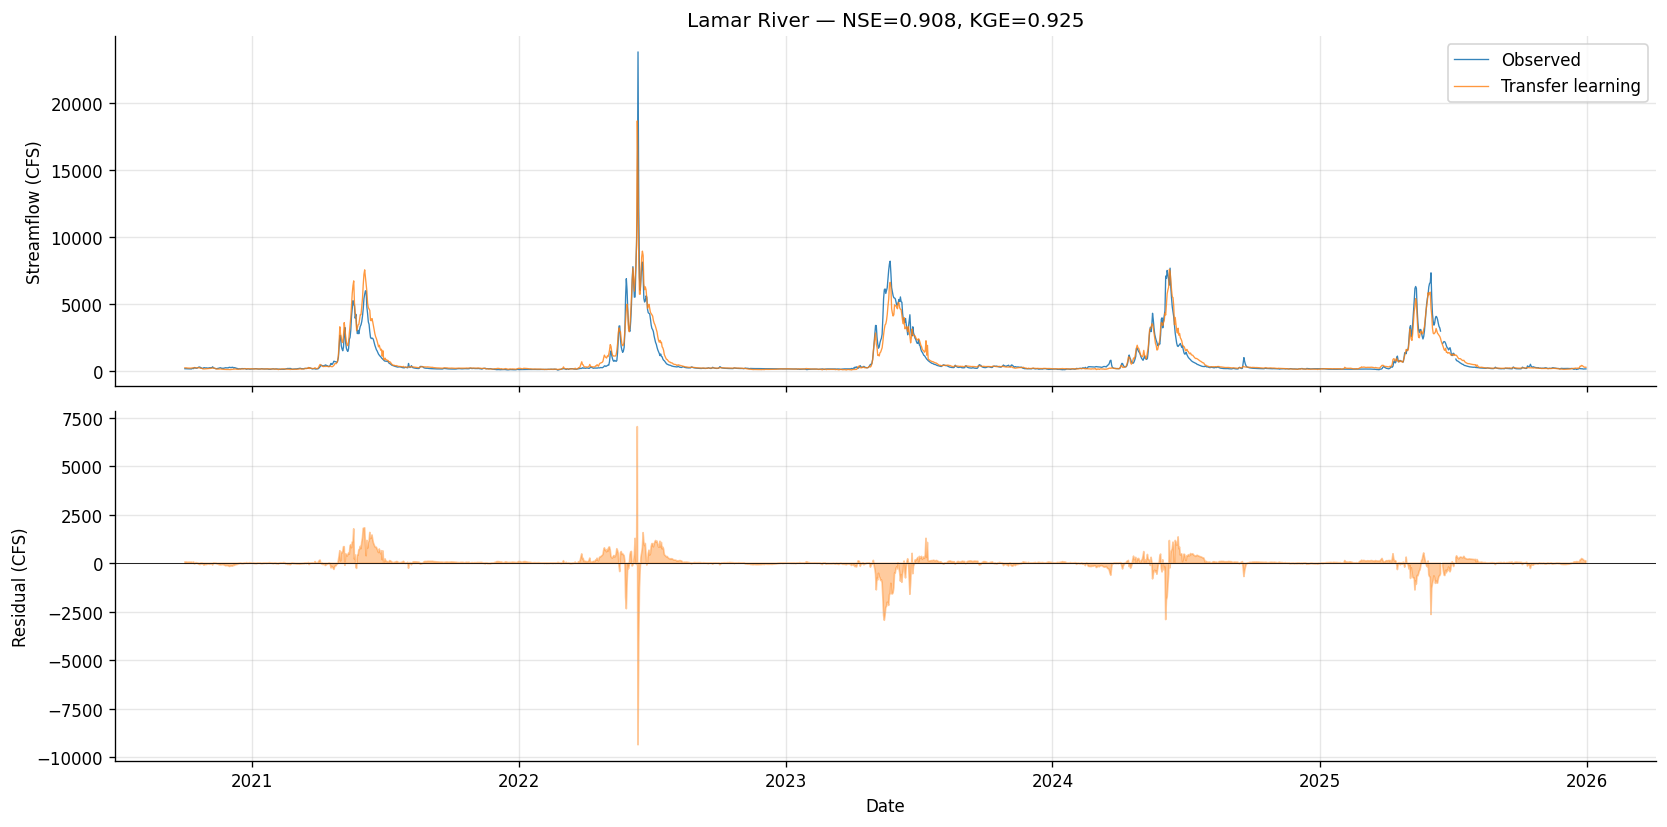

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Hydrograph
ax = axes[0]
ax.plot(lamar_ft_dates, lamar_ft_obs, color='#1f77b4', linewidth=0.8, label='Observed', alpha=0.9)
ax.plot(lamar_ft_dates, lamar_ft_sim, color='#ff7f0e', linewidth=0.8, label='Transfer learning', alpha=0.8)
ax.set_ylabel('Streamflow (CFS)')
ax.set_title(f'Lamar River — NSE={lamar_ft_metrics["NSE"]:.3f}, KGE={lamar_ft_metrics["KGE"]:.3f}')
ax.legend(loc='upper right')

# Residuals
ax = axes[1]
residuals = lamar_ft_sim - lamar_ft_obs
ax.fill_between(lamar_ft_dates, residuals, 0, color='#ff7f0e', alpha=0.4)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Residual (CFS)')
ax.set_xlabel('Date')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

### 3.2 Hoh River: Observed vs Predicted

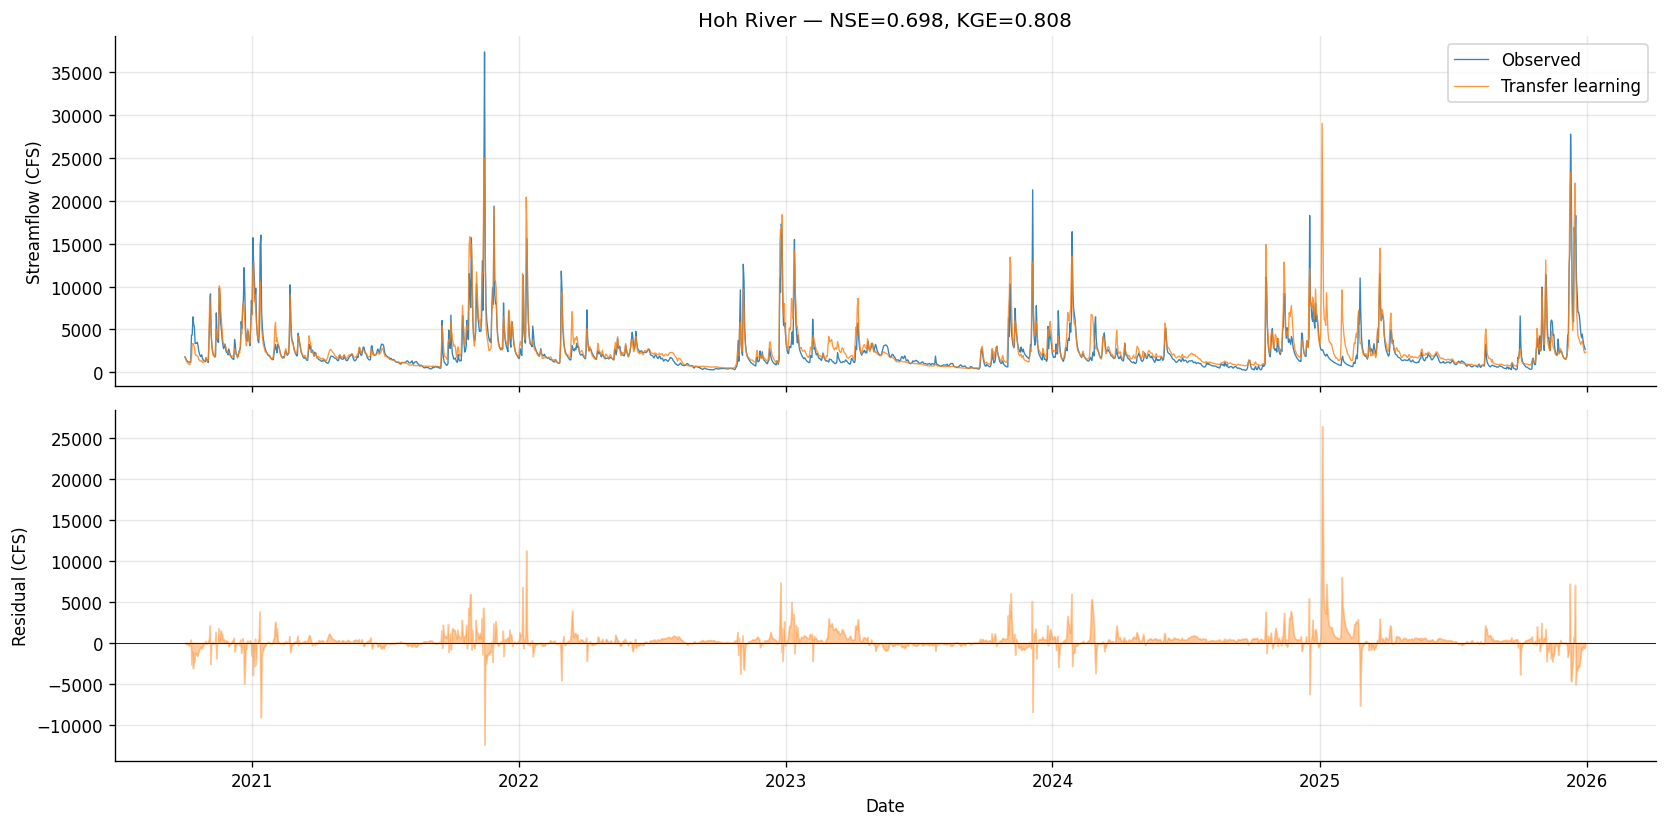

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Hydrograph
ax = axes[0]
ax.plot(hoh_ft_dates, hoh_ft_obs, color='#1f77b4', linewidth=0.8, label='Observed', alpha=0.9)
ax.plot(hoh_ft_dates, hoh_ft_sim, color='#ff7f0e', linewidth=0.8, label='Transfer learning', alpha=0.8)
ax.set_ylabel('Streamflow (CFS)')
ax.set_title(f'Hoh River — NSE={hoh_ft_metrics["NSE"]:.3f}, KGE={hoh_ft_metrics["KGE"]:.3f}')
ax.legend(loc='upper right')

# Residuals
ax = axes[1]
residuals = hoh_ft_sim - hoh_ft_obs
ax.fill_between(hoh_ft_dates, residuals, 0, color='#ff7f0e', alpha=0.4)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Residual (CFS)')
ax.set_xlabel('Date')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

### 3.3 Scatter Plots: Observed vs Simulated

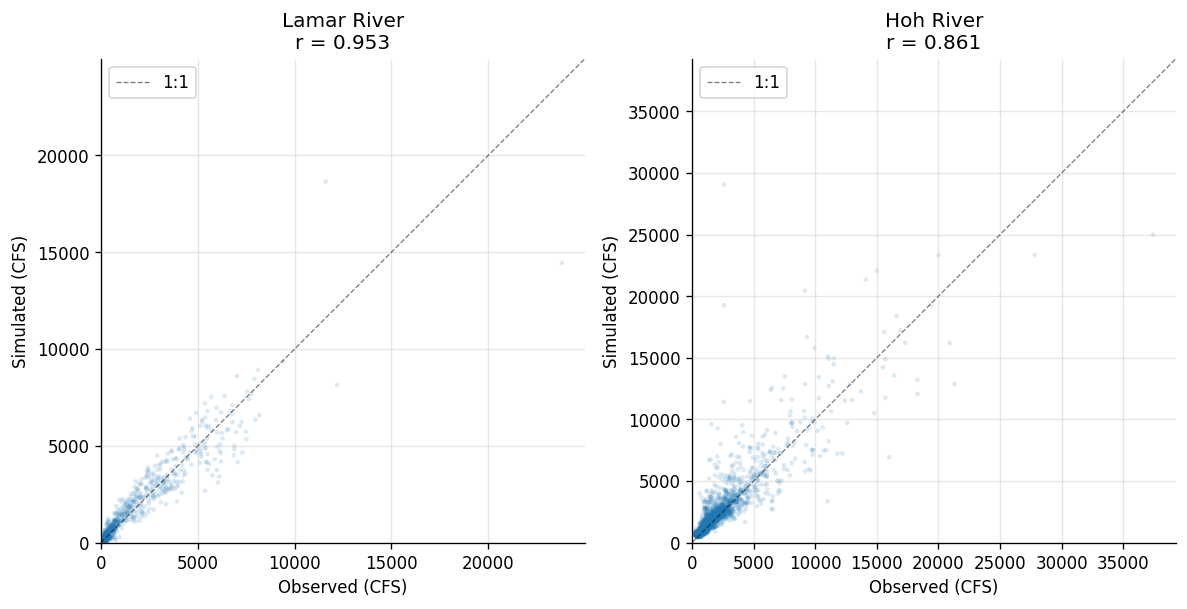

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, name, obs, sim, metrics in [
    (axes[0], 'Lamar River', lamar_ft_obs, lamar_ft_sim, lamar_ft_metrics),
    (axes[1], 'Hoh River', hoh_ft_obs, hoh_ft_sim, hoh_ft_metrics),
]:
    # Filter NaN
    mask = ~(np.isnan(obs) | np.isnan(sim))
    o, s = obs[mask], sim[mask]
    
    ax.scatter(o, s, alpha=0.15, s=8, color='#1f77b4', edgecolors='none')
    
    # 1:1 line
    lims = [0, max(o.max(), s.max()) * 1.05]
    ax.plot(lims, lims, 'k--', linewidth=0.8, alpha=0.5, label='1:1')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    
    ax.set_xlabel('Observed (CFS)')
    ax.set_ylabel('Simulated (CFS)')
    ax.set_title(f'{name}\nr = {metrics["Pearson-r"]:.3f}')
    ax.set_aspect('equal')
    ax.legend()

plt.tight_layout()
plt.show()

### 3.4 Monthly Performance Breakdown

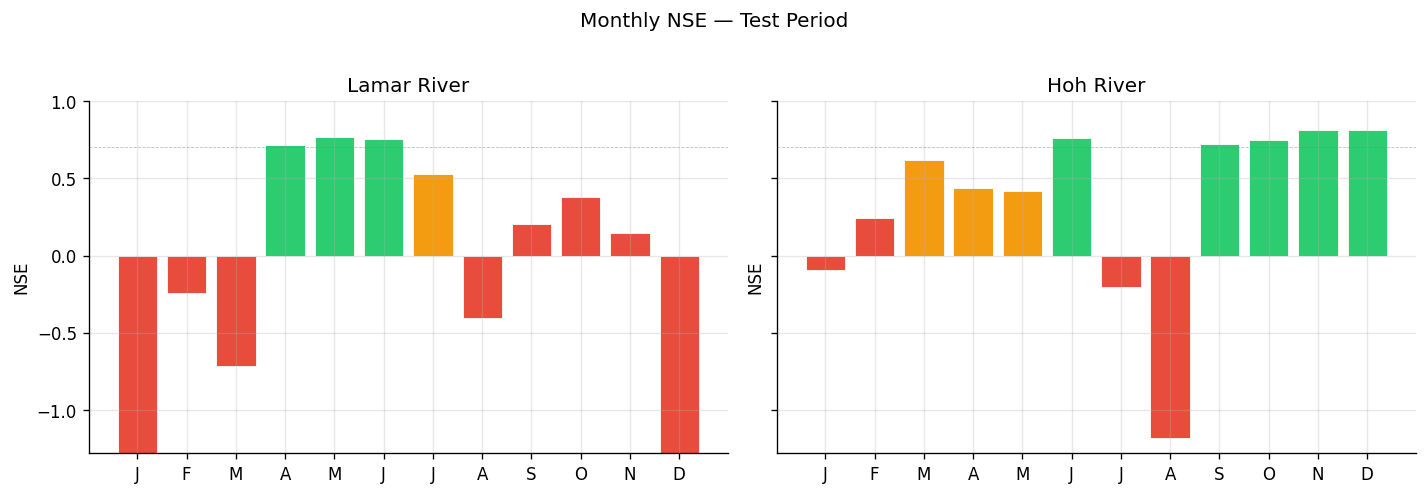

In [7]:
def monthly_nse(dates, obs, sim):
    """Compute NSE by calendar month."""
    df = pd.DataFrame({'obs': obs, 'sim': sim}, index=dates)
    df = df.dropna()
    results = {}
    for month in range(1, 13):
        m = df.index.month == month
        o, s = df.loc[m, 'obs'].values, df.loc[m, 'sim'].values
        ss_res = np.sum((o - s) ** 2)
        ss_tot = np.sum((o - np.mean(o)) ** 2)
        results[month] = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    return results

lamar_monthly = monthly_nse(lamar_ft_dates, lamar_ft_obs, lamar_ft_sim)
hoh_monthly = monthly_nse(hoh_ft_dates, hoh_ft_obs, hoh_ft_sim)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
month_names = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

for ax, name, monthly in [(axes[0], 'Lamar River', lamar_monthly), (axes[1], 'Hoh River', hoh_monthly)]:
    months = list(monthly.keys())
    values = list(monthly.values())
    colors = ['#2ecc71' if v >= 0.7 else '#f39c12' if v >= 0.4 else '#e74c3c' for v in values]
    ax.bar(months, values, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xticks(months)
    ax.set_xticklabels(month_names)
    ax.set_ylabel('NSE')
    ax.set_title(name)
    ax.axhline(0.7, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.set_ylim(min(0, min(values) - 0.1), 1.0)

plt.suptitle('Monthly NSE — Test Period', y=1.02)
plt.tight_layout()
plt.show()

### 3.5 Flow Duration Curves

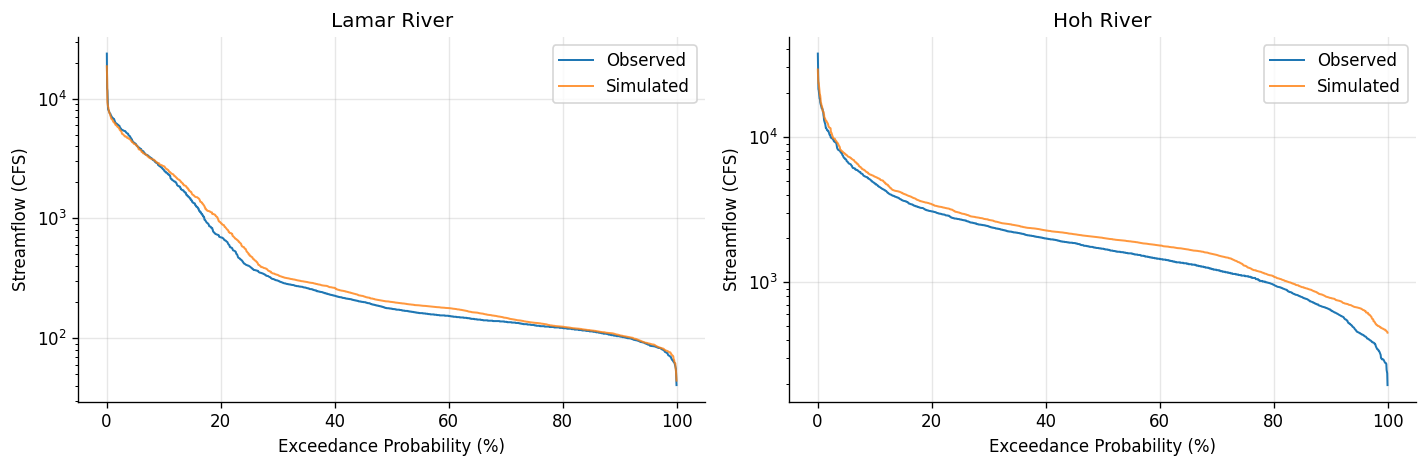

In [8]:
def flow_duration_curve(values):
    """Return exceedance probabilities and sorted flows."""
    sorted_vals = np.sort(values[~np.isnan(values)])[::-1]
    ranks = np.arange(1, len(sorted_vals) + 1)
    exceedance = ranks / (len(sorted_vals) + 1) * 100
    return exceedance, sorted_vals

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name, obs, sim in [
    (axes[0], 'Lamar River', lamar_ft_obs, lamar_ft_sim),
    (axes[1], 'Hoh River', hoh_ft_obs, hoh_ft_sim),
]:
    exc_obs, fdc_obs = flow_duration_curve(obs)
    exc_sim, fdc_sim = flow_duration_curve(sim)
    
    ax.semilogy(exc_obs, fdc_obs, color='#1f77b4', linewidth=1.2, label='Observed')
    ax.semilogy(exc_sim, fdc_sim, color='#ff7f0e', linewidth=1.2, label='Simulated', alpha=0.8)
    ax.set_xlabel('Exceedance Probability (%)')
    ax.set_ylabel('Streamflow (CFS)')
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.show()

### 3.6 Transfer Learning vs From-Scratch Comparison

Each from-scratch baseline is a separate single-basin CudaLSTM (hidden_size=32, NSE loss, lr=1e-3, 100 epochs) following Kratzert et al. (2024) Appendix A2. The smaller hidden size and lack of pre-training represent what is achievable with only local training data. Note that the from-scratch models use NSE loss while the fine-tuned models use MSE loss: both emphasize squared error, but the optimization scales differ.

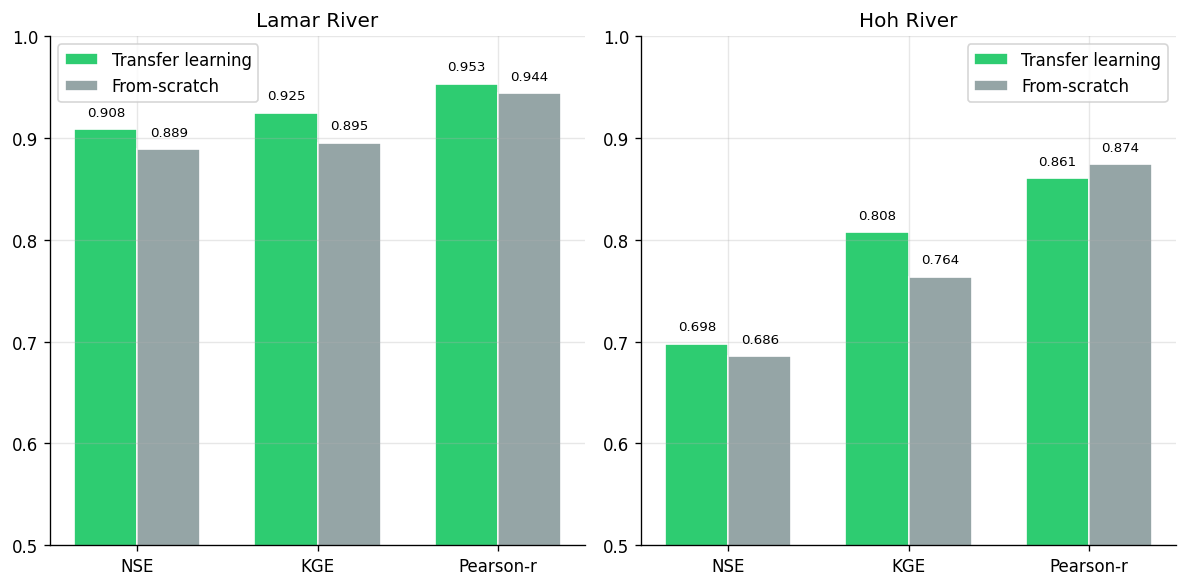

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, name, ft_m, sc_m in [
    (axes[0], 'Lamar River', lamar_ft_metrics, lamar_sc_metrics),
    (axes[1], 'Hoh River', hoh_ft_metrics, hoh_sc_metrics),
]:
    metrics_list = ['NSE', 'KGE', 'Pearson-r']
    ft_vals = [ft_m[m] for m in metrics_list]
    sc_vals = [sc_m[m] for m in metrics_list]
    
    x = np.arange(len(metrics_list))
    w = 0.35
    ax.bar(x - w/2, ft_vals, w, label='Transfer learning', color='#2ecc71', edgecolor='white')
    ax.bar(x + w/2, sc_vals, w, label='From-scratch', color='#95a5a6', edgecolor='white')
    
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_list)
    ax.set_ylim(0.5, 1.0)
    ax.set_title(name)
    ax.legend()

    # Add value labels
    for i, (fv, sv) in enumerate(zip(ft_vals, sc_vals)):
        ax.text(i - w/2, fv + 0.01, f'{fv:.3f}', ha='center', va='bottom', fontsize=8)
        ax.text(i + w/2, sv + 0.01, f'{sv:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

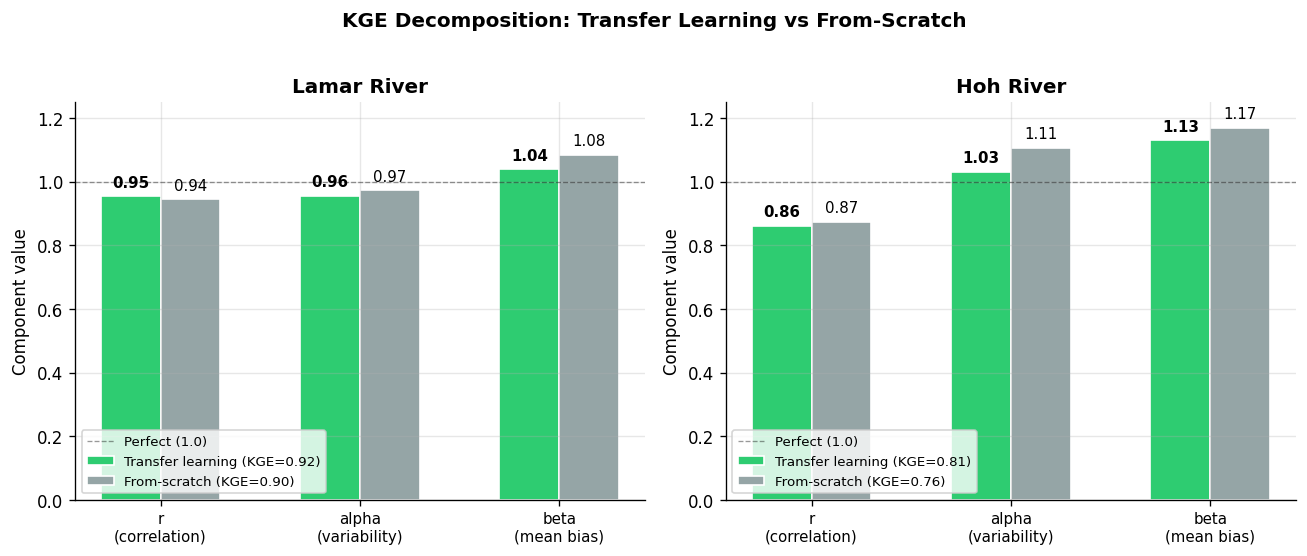

In [10]:
# KGE Decomposition: r (correlation), alpha (variability bias), beta (mean bias)
def kge_decomposition(obs, sim):
    """Compute KGE and its three components."""
    mask = ~(np.isnan(obs) | np.isnan(sim))
    o, s = obs[mask], sim[mask]
    r = np.corrcoef(o, s)[0, 1]
    alpha = np.std(s) / np.std(o)       # variability ratio
    beta = np.mean(s) / np.mean(o)      # mean bias ratio
    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)
    return {'KGE': kge, 'r (correlation)': r, 'alpha (variability)': alpha, 'beta (mean bias)': beta}

# Compute for all four model-basin combinations
kge_lamar_ft = kge_decomposition(lamar_ft_obs, lamar_ft_sim)
kge_lamar_sc = kge_decomposition(lamar_sc_obs, lamar_sc_sim)
kge_hoh_ft = kge_decomposition(hoh_ft_obs, hoh_ft_sim)
kge_hoh_sc = kge_decomposition(hoh_sc_obs, hoh_sc_sim)

components = ['r (correlation)', 'alpha (variability)', 'beta (mean bias)']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
w = 0.3
x = np.arange(len(components))
colors_ft = '#2ecc71'
colors_sc = '#95a5a6'

for ax, name, ft, sc in [
    (axes[0], 'Lamar River', kge_lamar_ft, kge_lamar_sc),
    (axes[1], 'Hoh River', kge_hoh_ft, kge_hoh_sc),
]:
    ft_vals = [ft[c] for c in components]
    sc_vals = [sc[c] for c in components]

    bars_ft = ax.bar(x - w/2, ft_vals, w, label=f'Transfer learning (KGE={ft["KGE"]:.2f})',
                     color=colors_ft, edgecolor='white')
    bars_sc = ax.bar(x + w/2, sc_vals, w, label=f'From-scratch (KGE={sc["KGE"]:.2f})',
                     color=colors_sc, edgecolor='white')

    # Perfect score reference line
    ax.axhline(1.0, color='black', linewidth=0.8, linestyle='--', alpha=0.4, label='Perfect (1.0)')

    # Value labels
    for i, (fv, sv) in enumerate(zip(ft_vals, sc_vals)):
        ax.text(i - w/2, fv + 0.02, f'{fv:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.text(i + w/2, sv + 0.02, f'{sv:.2f}', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels([c.split(' (')[0] + '\n(' + c.split('(')[1] for c in components], fontsize=9)
    ax.set_ylim(0.0, 1.25)
    ax.set_ylabel('Component value')
    ax.set_title(name, fontweight='bold')
    ax.legend(fontsize=8, loc='lower left')

fig.suptitle('KGE Decomposition: Transfer Learning vs From-Scratch', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.7 From-Scratch Baseline: Time Series

Hydrographs for the per-basin from-scratch models (hidden_size=32, NSE loss, 100 epochs) on the test period. Compare with sections 3.1-3.2 to see the transfer learning advantage visually.

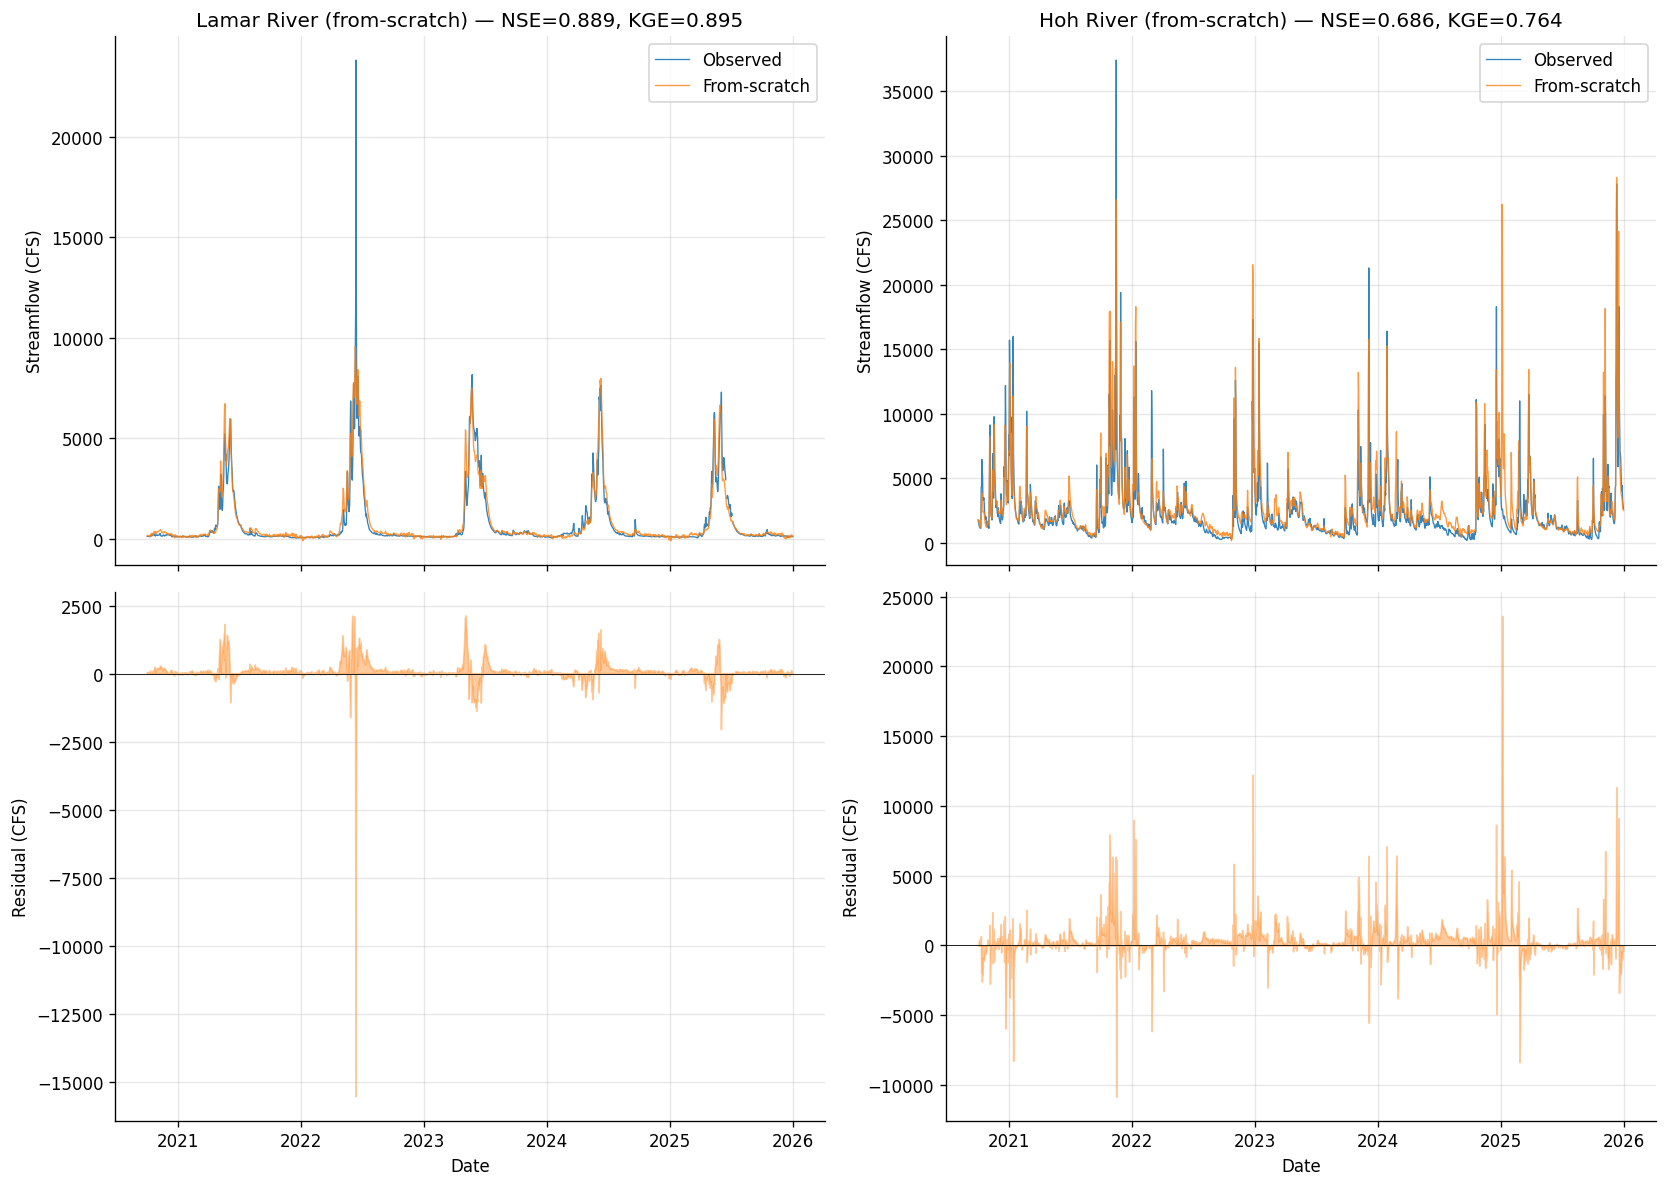

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex='col')

# Lamar scratch — hydrograph
ax = axes[0, 0]
ax.plot(lamar_sc_dates, lamar_sc_obs, color='#1f77b4', linewidth=0.8, label='Observed', alpha=0.9)
ax.plot(lamar_sc_dates, lamar_sc_sim, color='#ff7f0e', linewidth=0.8, label='From-scratch', alpha=0.8)
ax.set_ylabel('Streamflow (CFS)')
ax.set_title(f'Lamar River (from-scratch) — NSE={lamar_sc_metrics["NSE"]:.3f}, KGE={lamar_sc_metrics["KGE"]:.3f}')
ax.legend(loc='upper right')

# Lamar scratch — residuals
ax = axes[1, 0]
residuals = lamar_sc_sim - lamar_sc_obs
ax.fill_between(lamar_sc_dates, residuals, 0, color='#ff7f0e', alpha=0.4)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Residual (CFS)')
ax.set_xlabel('Date')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Hoh scratch — hydrograph
ax = axes[0, 1]
ax.plot(hoh_sc_dates, hoh_sc_obs, color='#1f77b4', linewidth=0.8, label='Observed', alpha=0.9)
ax.plot(hoh_sc_dates, hoh_sc_sim, color='#ff7f0e', linewidth=0.8, label='From-scratch', alpha=0.8)
ax.set_ylabel('Streamflow (CFS)')
ax.set_title(f'Hoh River (from-scratch) — NSE={hoh_sc_metrics["NSE"]:.3f}, KGE={hoh_sc_metrics["KGE"]:.3f}')
ax.legend(loc='upper right')

# Hoh scratch — residuals
ax = axes[1, 1]
residuals = hoh_sc_sim - hoh_sc_obs
ax.fill_between(hoh_sc_dates, residuals, 0, color='#ff7f0e', alpha=0.4)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Residual (CFS)')
ax.set_xlabel('Date')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

### 3.8 Peak Flow Analysis

The long-term application target is peak-flow prediction for flood warning. In this retrospective historical-data experiment, transfer learning's clearest advantage is better peak-flow behavior, especially on Hoh River. The simplified from-scratch baseline often compresses variability and misses large events, although the behavior differs by basin. This section quantifies and visualizes those differences on held-out historical test data.

#### Metric definitions

**High-flow NSE and KGE** are the standard NSE and KGE metrics computed only on days where observed flow exceeds the 90th percentile. This isolates model performance on relatively high-flow days, filtering out the many quiet days that dominate overall NSE. A model can have mediocre overall NSE but strong high-flow NSE if its errors are concentrated on low-flow days.

**Event peak ratio (median)** identifies individual storm events as local maxima in observed flow above P90 (minimum 7-day separation between events). For each observed peak, we find the highest simulated value within a ±7 day window and compute sim/obs. The median across all events is reported. A value of 1.0 is perfect; below 1.0 means the model systematically underpredicts peak magnitudes; above 1.0 means overprediction.

**Event peak correlation (Peak r)** takes those same matched event pairs (observed peak magnitude vs simulated peak magnitude) and computes their Pearson correlation. This measures whether the model gets the relative ordering of storms right: does it predict bigger peaks for bigger storms? A model could have a poor peak ratio (biased high or low) but still have high peak correlation if it correctly distinguishes large events from small ones.

In [12]:
from scipy.signal import find_peaks

def high_flow_metrics(obs, sim, threshold_pct=90):
    """Compute NSE and KGE on days above an observed flow percentile."""
    mask = ~(np.isnan(obs) | np.isnan(sim))
    o, s = obs[mask], sim[mask]
    threshold = np.percentile(o, threshold_pct)
    high = o >= threshold
    o_h, s_h = o[high], s[high]
    
    # NSE
    ss_res = np.sum((o_h - s_h) ** 2)
    ss_tot = np.sum((o_h - np.mean(o_h)) ** 2)
    nse = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    
    # KGE
    r = np.corrcoef(o_h, s_h)[0, 1]
    alpha = np.std(s_h) / np.std(o_h)
    beta = np.mean(s_h) / np.mean(o_h)
    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)
    
    return {'NSE (high)': nse, 'KGE (high)': kge,
            'N days': int(high.sum()), 'Threshold (CFS)': threshold}

def event_peak_metrics(dates, obs, sim, threshold_pct=90):
    """Event-based peak metrics: find observed peaks > P90, match sim peak within ±7 days.
    
    Returns median magnitude ratio and peak magnitude correlation.
    """
    p90 = np.nanpercentile(obs, threshold_pct)
    peak_idx, _ = find_peaks(obs, height=p90, distance=7)
    if len(peak_idx) == 0:
        return {'Median peak ratio': np.nan, 'Peak r': np.nan, 'N events': 0}
    
    mag_ratios = []
    sim_peaks = []
    obs_peaks = []
    for idx in peak_idx:
        lo = max(0, idx - 7)
        hi = min(len(obs), idx + 8)
        sim_peak = np.max(sim[lo:hi])
        mag_ratios.append(sim_peak / obs[idx])
        sim_peaks.append(sim_peak)
        obs_peaks.append(obs[idx])
    
    r = np.corrcoef(obs_peaks, sim_peaks)[0, 1] if len(obs_peaks) > 2 else np.nan
    return {
        'Median peak ratio': np.median(mag_ratios),
        'Peak r': r,
        'N events': len(peak_idx),
    }

rows = []
for name, ft_dates, ft_obs, ft_sim, sc_dates, sc_obs, sc_sim in [
    ('Lamar River', lamar_ft_dates, lamar_ft_obs, lamar_ft_sim,
     lamar_sc_dates, lamar_sc_obs, lamar_sc_sim),
    ('Hoh River', hoh_ft_dates, hoh_ft_obs, hoh_ft_sim,
     hoh_sc_dates, hoh_sc_obs, hoh_sc_sim),
]:
    ft_hf = high_flow_metrics(ft_obs, ft_sim)
    sc_hf = high_flow_metrics(sc_obs, sc_sim)
    ft_ep = event_peak_metrics(ft_dates, ft_obs, ft_sim)
    sc_ep = event_peak_metrics(sc_dates, sc_obs, sc_sim)
    rows.append({'Watershed': name, 'Model': 'Transfer learning',
                 **ft_hf, **ft_ep})
    rows.append({'Watershed': name, 'Model': 'From-scratch',
                 **sc_hf, **sc_ep})

hf_df = pd.DataFrame(rows).set_index(['Watershed', 'Model'])
hf_df.style.format({
    'NSE (high)': '{:.3f}', 'KGE (high)': '{:.3f}',
    'N days': '{:d}', 'Threshold (CFS)': '{:.1f}',
    'Median peak ratio': '{:.3f}', 'Peak r': '{:.3f}', 'N events': '{:d}',
}).set_caption('High-flow and event-based peak metrics (≥ 90th percentile)')

#### Annual peak magnitude

Observed vs simulated water-year maxima. Points below the 1:1 line indicate peak underestimation.

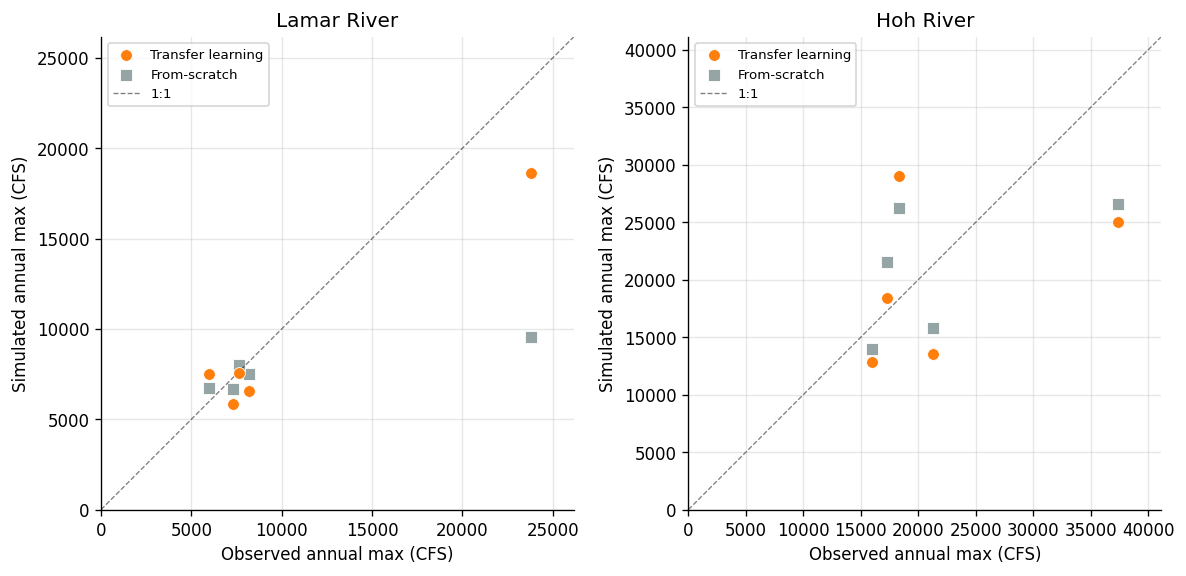

In [13]:
def annual_peaks(dates, obs, sim):
    """Return water-year annual maxima for obs and sim, excluding incomplete final WY."""
    df = pd.DataFrame({'obs': obs, 'sim': sim}, index=dates).dropna()
    # Water year: Oct start, label by the year containing Jan
    df['wy'] = df.index.year + (df.index.month >= 10).astype(int)
    # Exclude incomplete final water year (WY 2026 = Oct–Dec 2025 only)
    last_wy = df['wy'].max()
    if len(df[df['wy'] == last_wy]) < 300:
        df = df[df['wy'] != last_wy]
    peaks = df.groupby('wy').max()
    return peaks['obs'].values, peaks['sim'].values, peaks.index.values

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, name, ft_dates, ft_obs, ft_sim, sc_dates, sc_obs, sc_sim in [
    (axes[0], 'Lamar River', lamar_ft_dates, lamar_ft_obs, lamar_ft_sim,
     lamar_sc_dates, lamar_sc_obs, lamar_sc_sim),
    (axes[1], 'Hoh River', hoh_ft_dates, hoh_ft_obs, hoh_ft_sim,
     hoh_sc_dates, hoh_sc_obs, hoh_sc_sim),
]:
    ft_peak_obs, ft_peak_sim, ft_wys = annual_peaks(ft_dates, ft_obs, ft_sim)
    sc_peak_obs, sc_peak_sim, sc_wys = annual_peaks(sc_dates, sc_obs, sc_sim)
    
    ax.scatter(ft_peak_obs, ft_peak_sim, s=50, color='#ff7f0e', zorder=3,
               label='Transfer learning', edgecolors='white', linewidth=0.5)
    ax.scatter(sc_peak_obs, sc_peak_sim, s=50, color='#95a5a6', zorder=2,
               marker='s', label='From-scratch', edgecolors='white', linewidth=0.5)
    
    # 1:1 line
    all_vals = np.concatenate([ft_peak_obs, ft_peak_sim, sc_peak_obs, sc_peak_sim])
    lims = [0, np.max(all_vals) * 1.1]
    ax.plot(lims, lims, 'k--', linewidth=0.8, alpha=0.5, label='1:1')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    
    ax.set_xlabel('Observed annual max (CFS)')
    ax.set_ylabel('Simulated annual max (CFS)')
    ax.set_title(name)
    ax.set_aspect('equal')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

#### Peak event overlays

Zoomed views of the top 4 peak events per watershed, showing both models on the same axes. A ±30 day window around each observed annual maximum highlights how each model handles the peak hydrograph shape.

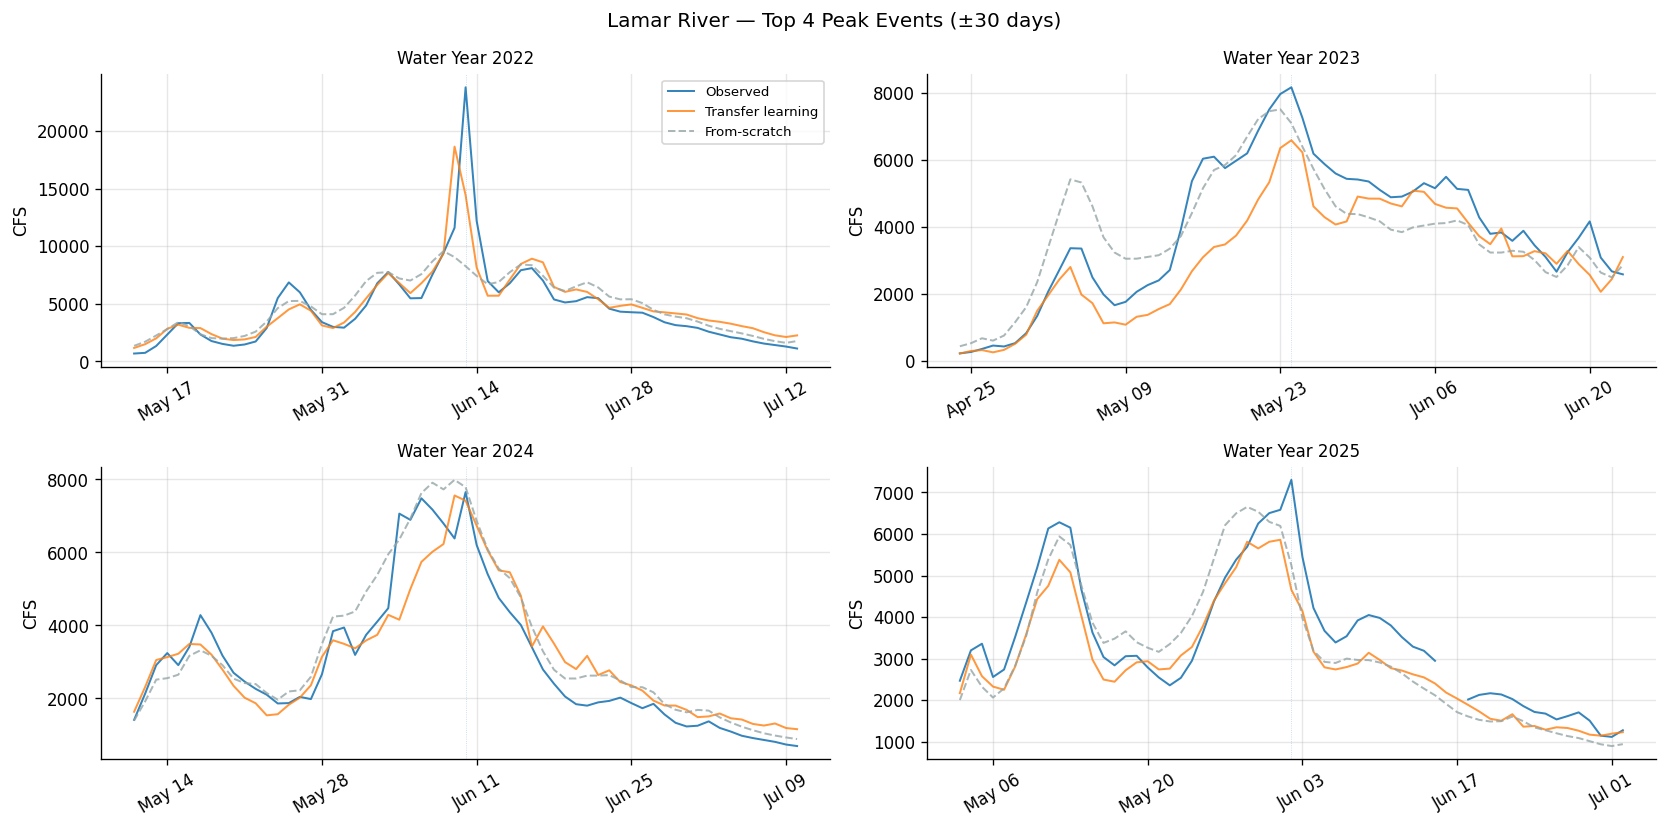

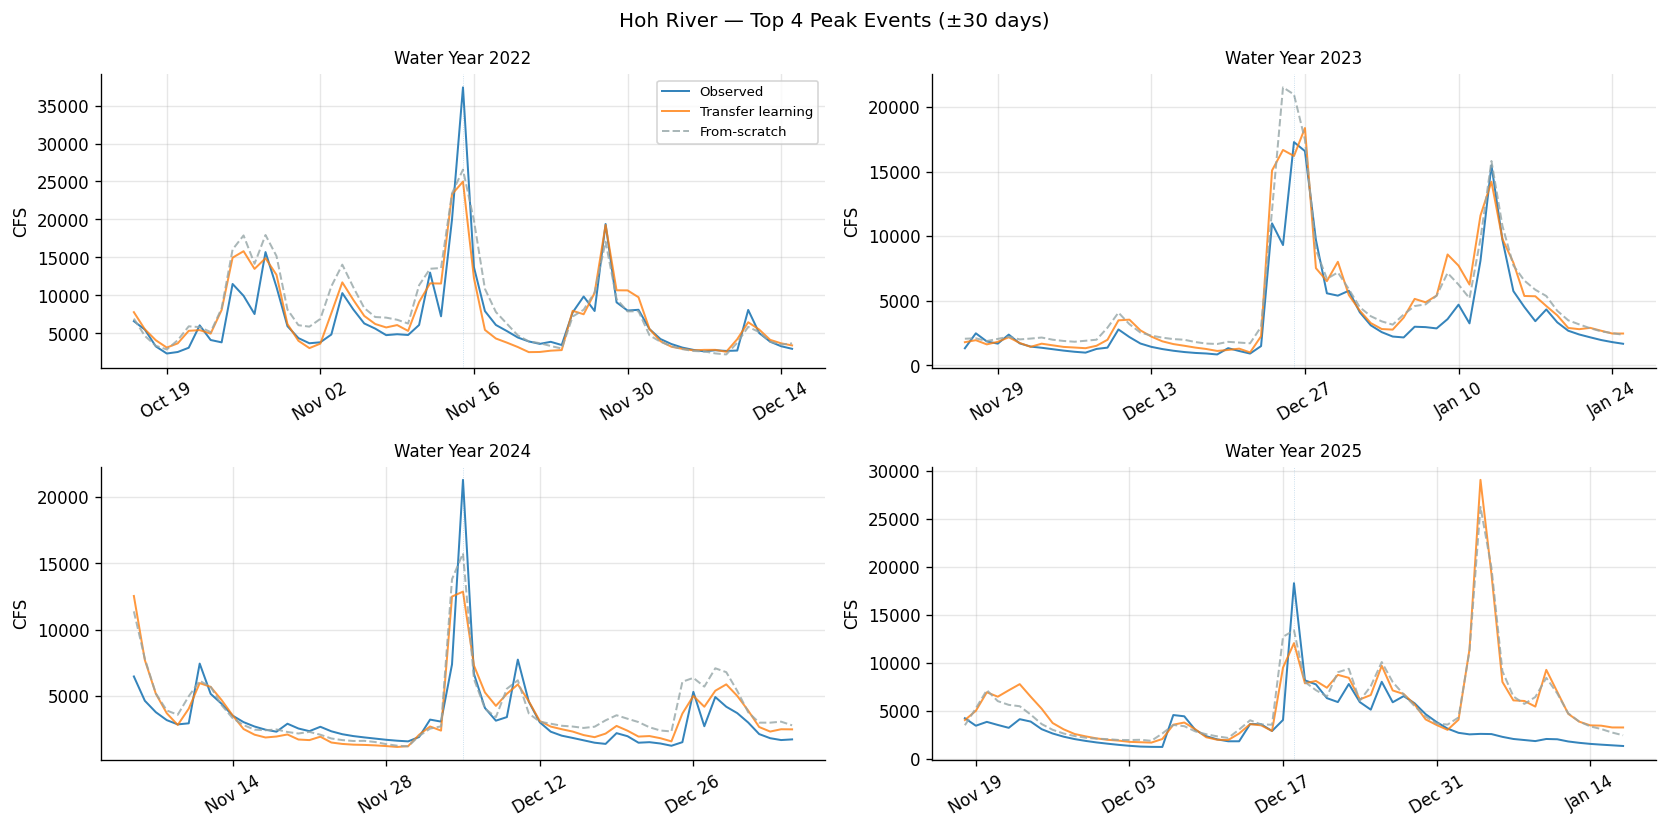

In [14]:
def find_peak_windows(dates, obs, n_peaks=4, window_days=30):
    """Find dates of top n annual peaks and return ±window slices."""
    df = pd.DataFrame({'obs': obs}, index=dates).dropna()
    df['wy'] = df.index.year + (df.index.month >= 10).astype(int)
    # Exclude incomplete final water year
    last_wy = df['wy'].max()
    if len(df[df['wy'] == last_wy]) < 300:
        df = df[df['wy'] != last_wy]
    # Get date of max flow in each water year
    peak_dates = df.groupby('wy')['obs'].idxmax()
    # Get peak magnitudes, sort descending, take top n
    peak_vals = df.loc[peak_dates.values, 'obs']
    top_idx = peak_vals.sort_values(ascending=False).index[:n_peaks]
    top_dates = sorted(top_idx)
    
    windows = []
    for pd_date in top_dates:
        start = pd_date - pd.Timedelta(days=window_days)
        end = pd_date + pd.Timedelta(days=window_days)
        windows.append((start, end, pd_date))
    return windows

for basin_name, ft_dates, ft_obs, ft_sim, sc_dates, sc_obs, sc_sim in [
    ('Lamar River', lamar_ft_dates, lamar_ft_obs, lamar_ft_sim,
     lamar_sc_dates, lamar_sc_obs, lamar_sc_sim),
    ('Hoh River', hoh_ft_dates, hoh_ft_obs, hoh_ft_sim,
     hoh_sc_dates, hoh_sc_obs, hoh_sc_sim),
]:
    windows = find_peak_windows(ft_dates, ft_obs, n_peaks=4, window_days=30)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 7))
    axes = axes.flatten()
    
    ft_df = pd.DataFrame({'obs': ft_obs, 'ft_sim': ft_sim}, index=ft_dates)
    sc_df = pd.DataFrame({'sc_sim': sc_sim}, index=sc_dates)
    
    for i, (start, end, peak_date) in enumerate(windows):
        ax = axes[i]
        ft_win = ft_df.loc[start:end]
        sc_win = sc_df.loc[start:end]
        
        ax.plot(ft_win.index, ft_win['obs'], color='#1f77b4', linewidth=1.2,
                label='Observed', alpha=0.9)
        ax.plot(ft_win.index, ft_win['ft_sim'], color='#ff7f0e', linewidth=1.2,
                label='Transfer learning', alpha=0.8)
        ax.plot(sc_win.index, sc_win['sc_sim'], color='#95a5a6', linewidth=1.2,
                label='From-scratch', linestyle='--', alpha=0.8)
        
        ax.axvline(peak_date, color='#1f77b4', linewidth=0.5, alpha=0.3, linestyle=':')
        wy = peak_date.year + (peak_date.month >= 10)
        ax.set_title(f'Water Year {wy}', fontsize=10)
        ax.set_ylabel('CFS')
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        ax.tick_params(axis='x', rotation=30)
        if i == 0:
            ax.legend(fontsize=8)
    
    plt.suptitle(f'{basin_name} — Top 4 Peak Events (±30 days)', fontsize=12)
    plt.tight_layout()
    plt.show()

## 4. How to Reproduce

### Environment setup
```bash
python3 -m venv .venv
source .venv/bin/activate
pip install -r requirements.txt  # torch, neuralhydrology, pandas, etc.
```

Requires NVIDIA GPU with CUDA (tested on GTX 1070).

### Data pipeline
```bash
# Download raw data
python src/download_lamar_river_data.py
python src/download_hoh_river_data.py
python src/download_gridmet_elevation_bands.py          # Lamar GridMET
python src/download_hoh_gridmet_elevation_bands.py      # Hoh GridMET

# Process into NeuralHydrology format
cd transfer_learning
python src/01_prep_climate_lumped.py
python src/02_convert_streamflow.py
python src/03_merge_to_netcdf.py
python src/04_calculate_attributes.py
```

### Training
All `nh-run` commands must be run from the `transfer_learning/` directory (configs use relative paths).

```bash
cd transfer_learning

# Fine-tune Lamar
nh-run finetune --config-file config/lamar_finetune_3var.yml

# Fine-tune Hoh
nh-run finetune --config-file config/hoh_finetune_3var.yml

# Evaluate
nh-run evaluate --run-dir runs/<run_name> --epoch 30 --period test
```

### Key files
| File | Purpose |
|------|---------|
| `config/lamar_finetune_3var.yml` | Lamar fine-tuning config |
| `config/hoh_finetune_3var.yml` | Hoh fine-tuning config |
| `base_model_modified/` | Pre-trained CAMELS checkpoint (required for fine-tuning) |
| `dashboard.py` | Interactive Streamlit evaluation dashboard (requires completed training runs) |
| `tests/` | Pipeline validation tests (`python -m pytest tests/ -v`) |

### Gotchas
1. **Configs must use relative paths.** Always run `nh-run` from `transfer_learning/`.
2. **`base_model_modified/` must exist** with the checkpoint and scaler files for fine-tuning to work.
3. **Variable name mismatch:** CAMELS uses `prcp(mm/day)`, local NetCDF uses `prcp_mm_day`. The `scripts/create_modified_base_model.py` script handles this mapping.
4. **Never shuffle temporal data.** Date splits must be strictly chronological.

## 5. Assessment & Next Steps

### Performance summary

The primary goal of this project is **peak-flow prediction for flood warning**. Overall accuracy between transfer learning and from-scratch models is comparable for Lamar, but transfer learning provides substantially better peak-flow prediction — most notably for the June 2022 flood event. For Hoh, transfer learning delivers a moderate improvement across all metrics. This notebook evaluates the models retrospectively on historical meteorological inputs and observed streamflow, which is an appropriate first-stage benchmark but does not represent operational forecast skill. Planned deployment will use downscaled MetData CFSv2 forecasts, which are temporally contiguous with the GridMET-based training inputs and therefore expected to reduce forcing-discontinuity issues. However, skill under operational CFSv2 forcing will differ from the retrospective results shown here and requires separate testing.

In [15]:
# Compute performance summary table dynamically
from IPython.display import display, Markdown

def volume_bias(obs, sim):
    """Percent volume bias: (sim - obs) / obs * 100."""
    return (np.nansum(sim) - np.nansum(obs)) / np.nansum(obs) * 100

def high_flow_nse_kge(obs, sim, threshold_pct=90):
    """Compute NSE and KGE on days above observed P90."""
    thresh = np.nanpercentile(obs, threshold_pct)
    mask = obs >= thresh
    o, s = obs[mask], sim[mask]
    nse = 1 - np.sum((o - s)**2) / np.sum((o - np.mean(o))**2)
    r = np.corrcoef(o, s)[0, 1]
    alpha = np.std(s) / np.std(o)
    beta = np.mean(s) / np.mean(o)
    kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)
    return nse, kge

def event_peak_summary(dates, obs, sim, threshold_pct=90):
    """Median peak magnitude ratio and peak correlation from event-based matching."""
    p90 = np.nanpercentile(obs, threshold_pct)
    peak_idx, _ = find_peaks(obs, height=p90, distance=7)
    if len(peak_idx) == 0:
        return np.nan, np.nan
    mag_ratios = []
    sim_peaks, obs_peaks = [], []
    for idx in peak_idx:
        lo, hi = max(0, idx - 7), min(len(obs), idx + 8)
        sp = np.max(sim[lo:hi])
        mag_ratios.append(sp / obs[idx])
        sim_peaks.append(sp)
        obs_peaks.append(obs[idx])
    r = np.corrcoef(obs_peaks, sim_peaks)[0, 1] if len(obs_peaks) > 2 else np.nan
    return np.median(mag_ratios), r

metrics_order = ['Overall NSE', 'High-flow NSE (≥P90)', 'High-flow KGE (≥P90)',
                 'Event peak ratio (median)', 'Event peak correlation', 'Volume bias']
table = pd.DataFrame(metrics_order, columns=['Metric'])

for name, ft_dates, ft_obs, ft_sim, ft_m, sc_dates, sc_obs, sc_sim, sc_m in [
    ('Lamar', lamar_ft_dates, lamar_ft_obs, lamar_ft_sim, lamar_ft_metrics,
     lamar_sc_dates, lamar_sc_obs, lamar_sc_sim, lamar_sc_metrics),
    ('Hoh', hoh_ft_dates, hoh_ft_obs, hoh_ft_sim, hoh_ft_metrics,
     hoh_sc_dates, hoh_sc_obs, hoh_sc_sim, hoh_sc_metrics),
]:
    ft_hf_nse, ft_hf_kge = high_flow_nse_kge(ft_obs, ft_sim)
    sc_hf_nse, sc_hf_kge = high_flow_nse_kge(sc_obs, sc_sim)
    ft_ep_ratio, ft_ep_r = event_peak_summary(ft_dates, ft_obs, ft_sim)
    sc_ep_ratio, sc_ep_r = event_peak_summary(sc_dates, sc_obs, sc_sim)
    ft_vbias = volume_bias(ft_obs, ft_sim)
    sc_vbias = volume_bias(sc_obs, sc_sim)
    
    table[f'{name} (transfer)'] = [
        f"{ft_m['NSE']:.3f}", f"{ft_hf_nse:.3f}", f"{ft_hf_kge:.3f}",
        f"{ft_ep_ratio:.3f}", f"{ft_ep_r:.3f}", f"{ft_vbias:+.1f}%"
    ]
    table[f'{name} (scratch)'] = [
        f"{sc_m['NSE']:.3f}", f"{sc_hf_nse:.3f}", f"{sc_hf_kge:.3f}",
        f"{sc_ep_ratio:.3f}", f"{sc_ep_r:.3f}", f"{sc_vbias:+.1f}%"
    ]

display(table.set_index('Metric').style.set_caption('Performance Summary (Test Period)'))

,Lamar (transfer),Lamar (scratch),Hoh (transfer),Hoh (scratch)
Metric,,,,
Overall NSE,0.908,0.889,0.698,0.686
High-flow NSE (≥P90),0.624,0.537,0.569,0.497
High-flow KGE (≥P90),0.780,0.654,0.781,0.742
Event peak ratio (median),1.080,1.208,1.000,0.965
Event peak correlation,0.760,0.595,0.826,0.830
Volume bias,+4.2%,+8.7%,+13.0%,+16.9%


In [16]:
# Generate dynamic key findings text
lamar_ft_hf_nse, lamar_ft_hf_kge = high_flow_nse_kge(lamar_ft_obs, lamar_ft_sim)
lamar_sc_hf_nse, lamar_sc_hf_kge = high_flow_nse_kge(lamar_sc_obs, lamar_sc_sim)
hoh_ft_hf_nse, hoh_ft_hf_kge = high_flow_nse_kge(hoh_ft_obs, hoh_ft_sim)
hoh_sc_hf_nse, hoh_sc_hf_kge = high_flow_nse_kge(hoh_sc_obs, hoh_sc_sim)
hoh_ft_vbias = volume_bias(hoh_ft_obs, hoh_ft_sim)

hoh_ft_ep_ratio, hoh_ft_ep_r = event_peak_summary(hoh_ft_dates, hoh_ft_obs, hoh_ft_sim)
hoh_sc_ep_ratio, hoh_sc_ep_r = event_peak_summary(hoh_sc_dates, hoh_sc_obs, hoh_sc_sim)
lamar_ft_ep_ratio, lamar_ft_ep_r = event_peak_summary(lamar_ft_dates, lamar_ft_obs, lamar_ft_sim)
lamar_sc_ep_ratio, lamar_sc_ep_r = event_peak_summary(lamar_sc_dates, lamar_sc_obs, lamar_sc_sim)

# Monthly NSE for flood season reference
def monthly_nse_single(dates, obs, sim, month):
    mask = np.array([d.month == month for d in dates]) & ~np.isnan(obs) & ~np.isnan(sim)
    o, s = obs[mask], sim[mask]
    ss_tot = np.sum((o - np.mean(o))**2)
    if ss_tot == 0:
        return np.nan
    return 1 - np.sum((o - s)**2) / ss_tot

lamar_june_nse = monthly_nse_single(lamar_ft_dates, lamar_ft_obs, lamar_ft_sim, 6)
hoh_monthly_nse = {m: monthly_nse_single(hoh_ft_dates, hoh_ft_obs, hoh_ft_sim, m) for m in range(1, 13)}

import calendar
hoh_nse_str = ', '.join(f'{calendar.month_abbr[m]}={hoh_monthly_nse[m]:.2f}' for m in [10, 11, 12, 1, 2, 3])

display(Markdown(f"""**Key findings:**
- **Lamar overall metrics are similar between models** (NSE {lamar_ft_metrics['NSE']:.3f} vs {lamar_sc_metrics['NSE']:.3f}, KGE {lamar_ft_metrics['KGE']:.3f} vs {lamar_sc_metrics['KGE']:.3f}). The case for transfer learning on Lamar is **peak-flow prediction**: high-flow KGE improves from {lamar_sc_hf_kge:.3f} to {lamar_ft_hf_kge:.3f}, and the transfer learning model better captures the June 2022 flood event (the largest on record in the test period). Event peak tracking is also stronger (median ratio {lamar_ft_ep_ratio:.3f} vs {lamar_sc_ep_ratio:.3f}, correlation {lamar_ft_ep_r:.3f} vs {lamar_sc_ep_r:.3f}).
- **Transfer learning moderately improves Hoh** (KGE {hoh_ft_metrics['KGE']:.3f} vs {hoh_sc_metrics['KGE']:.3f}, NSE {hoh_ft_metrics['NSE']:.3f} vs {hoh_sc_metrics['NSE']:.3f}). Pre-training on 531 diverse CAMELS basins likely provides a better starting point for Hoh's flashy rainfall-runoff dynamics.
- **Hoh seasonal performance is uneven.** Monthly NSE varies considerably ({hoh_nse_str}), with some months well-captured and others (e.g. January, NSE={hoh_monthly_nse[1]:.2f}) underperforming. Lamar June snowmelt is well-captured (NSE={lamar_june_nse:.2f}).
- **Hoh volume bias:** {hoh_ft_vbias:+.1f}% (model overpredicts total streamflow volume)."""))

**Key findings:**
- **Lamar overall metrics are similar between models** (NSE 0.908 vs 0.889, KGE 0.925 vs 0.895). The case for transfer learning on Lamar is **peak-flow prediction**: high-flow KGE improves from 0.654 to 0.780, and the transfer learning model better captures the June 2022 flood event (the largest on record in the test period). Event peak tracking is also stronger (median ratio 1.080 vs 1.208, correlation 0.760 vs 0.595).
- **Transfer learning moderately improves Hoh** (KGE 0.808 vs 0.764, NSE 0.698 vs 0.686). Pre-training on 531 diverse CAMELS basins likely provides a better starting point for Hoh's flashy rainfall-runoff dynamics.
- **Hoh seasonal performance is uneven.** Monthly NSE varies considerably (Oct=0.75, Nov=0.81, Dec=0.82, Jan=-0.09, Feb=0.24, Mar=0.62), with some months well-captured and others (e.g. January, NSE=-0.09) underperforming. Lamar June snowmelt is well-captured (NSE=0.76).
- **Hoh volume bias:** +13.0% (model overpredicts total streamflow volume).

### Next steps (prioritized for peak/flood prediction)

**1. High-flow weighted loss (fine-tuning only)**
Weight the MSE loss toward high-flow days during fine-tuning so the model prioritizes peak accuracy over baseflow fit. NeuralHydrology supports custom loss functions. Config-level change only, no base model retrain.

**2. MC-Dropout prediction intervals (inference only)**
The model already has dropout=0.4; MC-Dropout runs inference N times with dropout enabled to derive prediction intervals. No retraining needed.

**3. Hoh volume bias investigation (diagnostic)**
Investigate the source of the +13% volume bias on Hoh. Compare GridMET precipitation against PRISM or rain gauge data to determine whether the bias originates in the forcing data or the model.

**4. LSTM cell state inspection (diagnostic)**
Transfer CudaLSTM weights to a [CustomLSTM](https://neuralhydrology.readthedocs.io/en/latest/tutorials/inspect-lstm.html) to inspect internal cell states and gate activations, following the approach in Kratzert et al. (2019).

**5. SNOTEL SWE as 4th dynamic input (requires base model retrain)**
Adding SWE requires retraining the base model on all 531 CAMELS basins with a gridded SWE product. **Defer unless other improvements plateau.**

## References

Chen, X., Zhang, Y., Ye, A., Li, J., Hsu, K., & Sorooshian, S. (2025). Fine-tuning long short-term memory models for seamless transition in hydrological modelling: From pre-training to post-application. *Environmental Modelling & Software*, 186, 106350. https://doi.org/10.1016/j.envsoft.2025.106350

Kratzert, F., Gauch, M., Klotz, D., & Nearing, G. (2024). HESS Opinions: Never train a Long Short-Term Memory (LSTM) network on a single basin. *Hydrology and Earth System Sciences*, 28(17), 4187–4201. https://doi.org/10.5194/hess-28-4187-2024

NeuralHydrology fine-tuning tutorial: https://neuralhydrology.readthedocs.io/en/latest/tutorials/finetuning.html